# BCSD Pipeline Demo - New Orchestration System

this notebook demonstrates the new CLI based BCSD pipeline with:
- Pydantic configuration system
- automatic caching with S3
- three-stage architecture (observations → historical → scenario)
- environment-based isolation (qa/staging/production)

we'll run a South Africa regional downscaling and visualize the results.

In [1]:
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr

from srm.bcsd_config import BCSDConfig
from srm.orchestration import BCSDOrchestrator
from srm.pipeline import BCSDPipeline

## 1. Define Configuration

we'll configure a BCSD run for:
- GCM: CESM2-WACCM
- Variable: tas (temperature)
- Scenario: SSP245
- Region: South Africa
- Environment: qa (for testing)

In [2]:
# Define South Africa bounds
df = duckdb.sql(
    """
    install httpfs; load httpfs;
    install spatial; load spatial;
    SELECT name, ST_AsText(geom) as geometry
    FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json')
    WHERE NAME = 'South Africa'
    """
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds with 2-degree buffer
lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
bounds = [lat_min - 2, lat_max + 2, lon_min - 2, lon_max + 2]

print(f"South Africa subset bounds: {bounds}")

South Africa subset bounds: [np.float64(-48.9634743806813), np.float64(-20.145569005377542), np.float64(14.446764467644684), np.float64(39.88857888578887)]


In [3]:
# Create configuration
config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable="tas",
    ensemble_member="r1i1p1f1",
    scenario="SSP245",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
    cache_dir="s3://carbonplan-scratch/srm/bcsd-cache",
    output_dir="s3://carbonplan-scratch/srm/outputs",
    environment="qa",  # Use 'qa' for testing
    verbose=True,
)

print(f"Run ID: {config.run_id}")
print(f"Config hash: {config.config_hash}")
print(f"Detrend data: {config.detrend_data}")

Run ID: CESM2-WACCM_tas_000_SSP245_subset
Config hash: b0e14bee2be8
Detrend data: True


## 2. Run Pipeline

we can run the pipeline either:
- **Locally**: `use_coiled=False` - good for testing small regions
- **Coiled**: `use_coiled=True` - for large-scale runs

for this demo, we'll run locally since it's a small region.

In [4]:
# Initialize pipeline
pipeline = BCSDPipeline(config)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path}")

Stage 1: Prepare observations (regrid ERA5 to GCM grid)
✓ Observations cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/obs/CESM2-WACCM_tas_lat-48.9634743806813to-20.145569005377542_lon14.446764467644684to39.88857888578887_obs_regridded.zarr

Stage 2: Fit historical (debias and downscale historical period)
✓ Historical cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/historical/CESM2-WACCM_tas_000_lat-48.9634743806813to-20.145569005377542_lon14.446764467644684to39.88857888578887_historical.zarr

Stage 3: Transform scenario (debias and downscale future)
✓ Scenario output at: s3://carbonplan-scratch/srm/outputs/qa/CESM2-WACCM_tas_000_lat-48.9634743806813to-20.145569005377542_lon14.446764467644684to39.88857888578887_SSP245.zarr


## 3. Load Results from Cache

the pipeline automatically caches intermediate artifacts and final outputs. let's load them for visualization.

In [5]:
# Load cached artifacts
obs_coarse = xr.open_zarr(obs_path)[config.variable]
historical_downscaled = xr.open_zarr(hist_path)[config.variable]
scenario_downscaled = xr.open_zarr(scenario_path)[config.variable]

print("Observations (coarse):", obs_coarse)
print("Historical downscaled:", historical_downscaled)
print("Scenario downscaled:", scenario_downscaled)

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xf99aef851450>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xf99aeedf1bb0>, 13208.780625012)])']
connector: <aiohttp.connector.TCPConnector object at 0xf99aef851590>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xf99aeeebd810>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xf99aeedf14f0>, 13208.782568903)])']
connector: <aiohttp.connector.TCPConnector object at 0xf99aeeebd590>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xf99aef853d90>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xf99aeedf1970>, 13208.784930706)])']
connector: <aiohttp.connector.TCPConnector object at 0xf99aef8511d0>


Observations (coarse): <xarray.DataArray 'tas' (time: 23741, lat: 31, lon: 20)> Size: 59MB
dask.array<open_dataset-tas, shape=(23741, 31, 20), dtype=float32, chunksize=(23741, 31, 20), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 190kB 1950-01-01 1950-01-02 ... 2014-12-31
  * lat      (lat) float64 248B -48.53 -47.59 -46.65 ... -22.15 -21.2 -20.26
  * lon      (lon) float64 160B 15.0 16.25 17.5 18.75 ... 35.0 36.25 37.5 38.75
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K
Historical downscaled: <xarray.DataArray 'tas' (time: 13505, lat: 115, lon: 102)> Size: 634MB
dask.array<open_dataset-tas, shape=(13505, 115, 102), dtype=float32, chunksize=(2131, 115, 102), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 108kB 1978-01-01 1978-01-02 ... 2014-12-31
    dayofyear  (time) int64 108kB dask.array<chunksize=(13505,), meta=np.ndarray>
  * lat        (lat) float32 460B -48.75 -48.5 -48.25 ... -20.

In [6]:
# Also load the raw GCM data for comparison
from srm.downscaling_utils import get_experiment, get_obs, subset_space

# Load fine-resolution observations
obs_fine = get_obs(var=config.variable)
obs_fine = subset_space(obs_fine, bounds)
obs_fine = obs_fine.sel(time=slice("1978", "2014"))

# Load coarse GCM data
model_hist_raw = get_experiment(gcm=config.gcm, scenario="Historical", var=config.variable)
if "ensemble_member" in model_hist_raw.dims:
    model_hist_raw = model_hist_raw.sel(ensemble_member=config.ensemble_member)
model_hist_raw = subset_space(model_hist_raw, bounds)
model_hist_raw = model_hist_raw.sel(time=slice("1978", "2014"))

model_scenario_raw = get_experiment(gcm=config.gcm, scenario=config.scenario, var=config.variable)
model_scenario_raw = model_scenario_raw.sel(ensemble_member=config.ensemble_member)
model_scenario_raw = subset_space(model_scenario_raw, bounds)
model_scenario_raw = model_scenario_raw.sel(time=slice("2015", "2100"))

print("Loaded raw GCM data for comparison")

Loaded raw GCM data for comparison


## 4. Visualize Results at Cape Town

extract time series at Cape Town and compare:
1. raw model output (coarse)
2. debiased model output (coarse)
3. debiased + downscaled output (fine resolution)

In [7]:
# Get Cape Town coordinates
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_lon = float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x.item())
cape_town_lat = float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y.item())

print(f"Cape Town: ({cape_town_lat:.2f}°, {cape_town_lon:.2f}°)")

Cape Town: (-33.92°, 18.43°)


In [8]:
# Extract Cape Town data
obs_fine_ct = obs_fine.sel(lat=cape_town_lat, lon=cape_town_lon, method="nearest").compute()
obs_coarse_ct = obs_coarse.sel(lat=cape_town_lat, lon=cape_town_lon, method="nearest").compute()

model_hist_raw_ct = model_hist_raw.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
historical_downscaled_ct = historical_downscaled.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()

model_scenario_raw_ct = model_scenario_raw.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
scenario_downscaled_ct = scenario_downscaled.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()

print("✓ Extracted Cape Town time series")

✓ Extracted Cape Town time series


### Distribution Comparison: Raw → Debiased → Downscaled

this shows how BCSD transforms the model output:
- **Left**: Raw GCM output (biased, coarse)
- **Middle**: after bias correction (matches obs distribution, coarse)
- **Right**: after bias correction + spatial disaggregation (fine resolution)

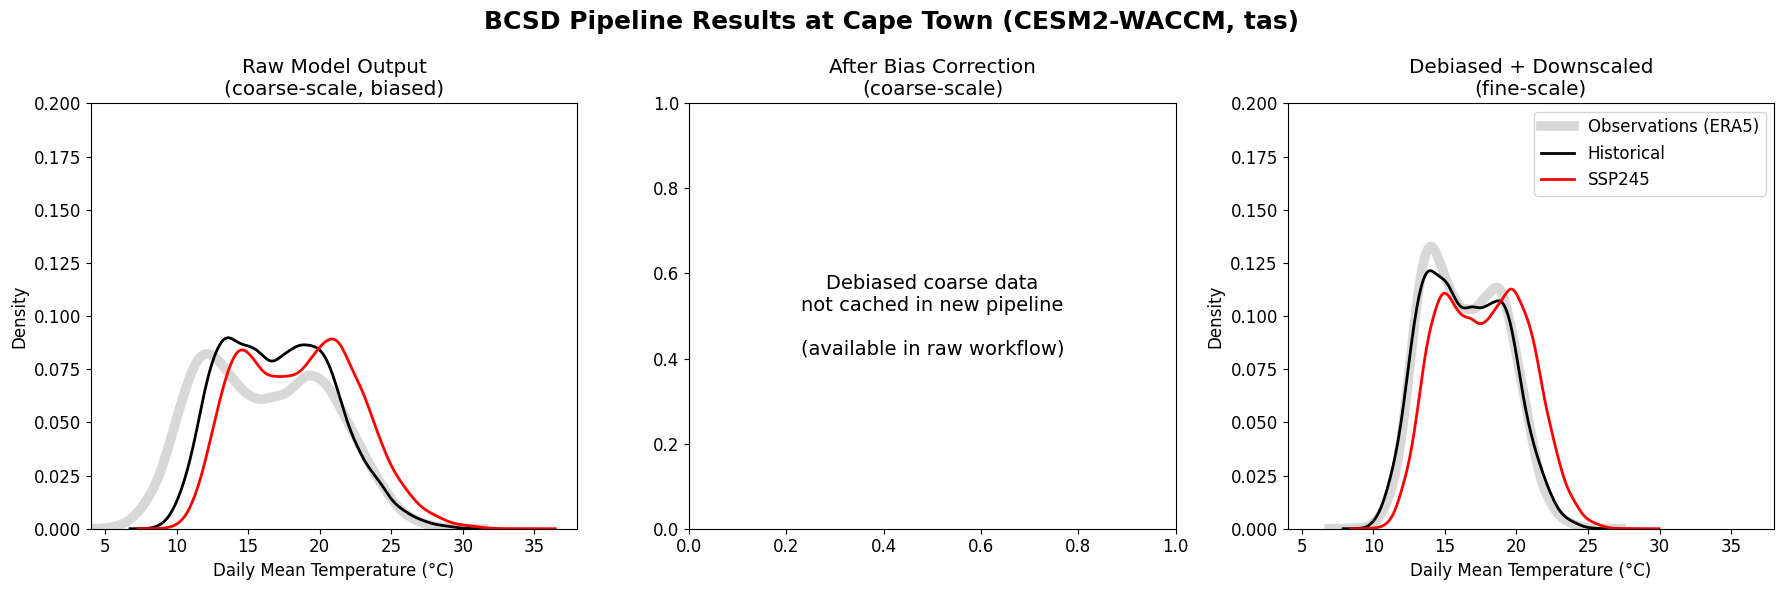

In [9]:
# Note: For the debiased coarse data, we need to compute it since pipeline doesn't cache it
# In production, we might want to cache the intermediate debiased-but-not-downscaled data

# Create figure
plt.rcParams["font.size"] = 12
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ["black", "red"]
labels = ["Historical", "SSP245"]


def format_subplot(ax, res="coarse"):
    """Add observation distribution to subplot"""
    if res == "coarse":
        sns.kdeplot(
            obs_coarse_ct.values - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
            ax=ax,
        )
    elif res == "fine":
        sns.kdeplot(
            obs_fine_ct.values - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
            ax=ax,
        )
    ax.set_ylim([0, 0.2])
    ax.set_xlim([4, 38])
    ax.set_xlabel("Daily Mean Temperature (°C)")


# Panel 1: Raw model output
ax = axes[0]
format_subplot(ax, res="coarse")
sns.kdeplot(
    model_hist_raw_ct.values - 273.15,
    label=labels[0],
    color=colors[0],
    linewidth=2,
    ax=ax,
)
sns.kdeplot(
    model_scenario_raw_ct.values - 273.15,
    label=labels[1],
    color=colors[1],
    linewidth=2,
    ax=ax,
)
ax.set_title("Raw Model Output\n(coarse-scale, biased)")

# Panel 2: Note - we don't have direct access to debiased-but-not-downscaled
# This would require modifying the pipeline to cache that intermediate step
# For now, we'll skip this panel or note it as unavailable
ax = axes[1]
ax.text(
    0.5,
    0.5,
    "Debiased coarse data\nnot cached in new pipeline\n\n(available in raw workflow)",
    ha="center",
    va="center",
    transform=ax.transAxes,
    fontsize=14,
)
ax.set_title("After Bias Correction\n(coarse-scale)")

# Panel 3: Downscaled output
ax = axes[2]
format_subplot(ax, res="fine")
sns.kdeplot(
    historical_downscaled_ct.values - 273.15,
    label=labels[0],
    color=colors[0],
    linewidth=2,
    ax=ax,
)
sns.kdeplot(
    scenario_downscaled_ct.values - 273.15,
    label=labels[1],
    color=colors[1],
    linewidth=2,
    ax=ax,
)
ax.set_title("Debiased + Downscaled\n(fine-scale)")

plt.suptitle(
    f"BCSD Pipeline Results at Cape Town ({config.gcm}, {config.variable})",
    fontsize=18,
    fontweight="bold",
)

axes[2].legend(fontsize=12)
plt.tight_layout()
plt.show()

### Time Series Comparison

let's also look at the annual mean temperature trends:

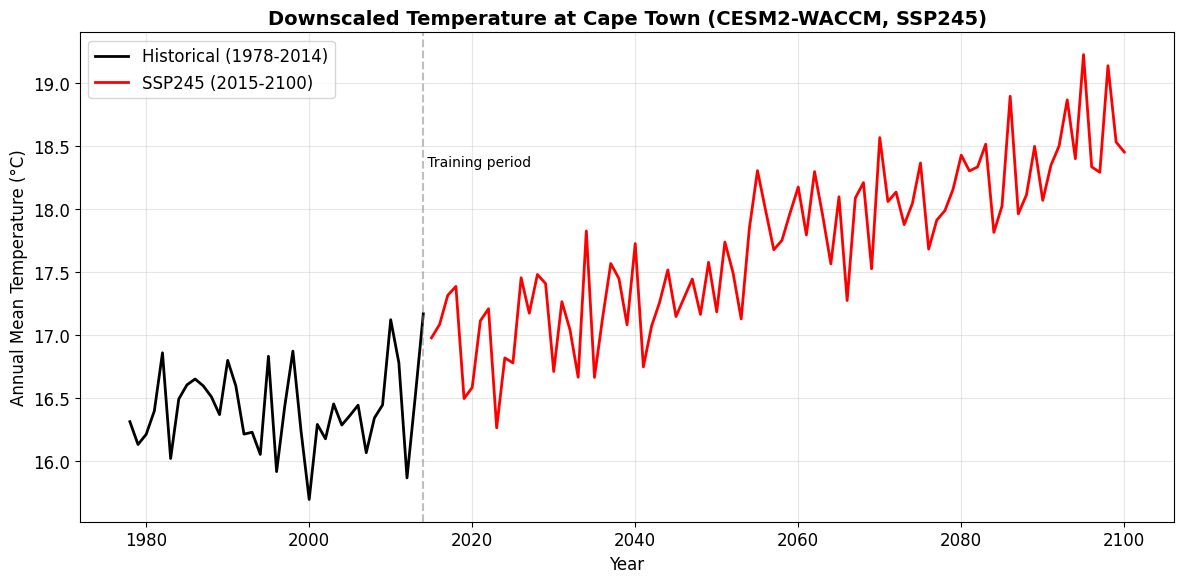

Historical mean: 16.42°C
2090s mean: 18.56°C
Warming: 2.15°C


In [10]:
# Compute annual means
hist_annual = historical_downscaled_ct.groupby("time.year").mean()
scenario_annual = scenario_downscaled_ct.groupby("time.year").mean()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    hist_annual.year,
    hist_annual - 273.15,
    color="black",
    linewidth=2,
    label="Historical (1978-2014)",
)
ax.plot(
    scenario_annual.year,
    scenario_annual - 273.15,
    color="red",
    linewidth=2,
    label="SSP245 (2015-2100)",
)

ax.axvline(2014, color="gray", linestyle="--", alpha=0.5)
ax.text(2014, ax.get_ylim()[1] * 0.95, " Training period", fontsize=10, va="top")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Annual Mean Temperature (°C)", fontsize=12)
ax.set_title(
    f"Downscaled Temperature at Cape Town ({config.gcm}, {config.scenario})",
    fontsize=14,
    fontweight="bold",
)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Historical mean: {(hist_annual.mean() - 273.15).values:.2f}°C")
print(f"2090s mean: {(scenario_annual.sel(year=slice(2090, 2100)).mean() - 273.15).values:.2f}°C")
print(
    f"Warming: {(scenario_annual.sel(year=slice(2090, 2100)).mean() - hist_annual.mean()).values:.2f}°C"
)

## 5. Check Cache Status

the new pipeline automatically manages caching. let's inspect what's cached:

In [11]:
# Create orchestrator to check status
orchestrator = BCSDOrchestrator()
status = orchestrator.get_status([config])

print("Cache Status:")
print("=" * 60)
for stage, info in status.items():
    cached = info["cached"]
    total = info["total"]
    pct = (cached / total * 100) if total > 0 else 0
    print(f"{stage:25s}: {cached}/{total} ({pct:.0f}%) cached")
    if info["missing"]:
        print(f"  Missing: {', '.join(info['missing'])}")

Cache Status:
prepare_observations     : 1/1 (100%) cached
fit_historical           : 1/1 (100%) cached
transform_scenario       : 1/1 (100%) cached


In [12]:
# List all artifacts in cache
artifacts = pipeline.cache.list_artifacts()
print(f"\nTotal artifacts in {config.environment} environment: {len(artifacts)}")
print("\nArtifact paths:")
for path in artifacts:
    print(f"  {path}")


Total artifacts in qa environment: 21

Artifact paths:
  s3://carbonplan-scratch/srm/bcsd-cache/qa/historical/CESM2-WACCM_pr_000_global_historical.zarr
  s3://carbonplan-scratch/srm/bcsd-cache/qa/historical/CESM2-WACCM_pr_000_lat-35.0to-22.0_lon16.0to33.0_historical.zarr
  s3://carbonplan-scratch/srm/bcsd-cache/qa/historical/CESM2-WACCM_tas_000_global_historical.zarr
  s3://carbonplan-scratch/srm/bcsd-cache/qa/historical/CESM2-WACCM_tas_000_lat-35.0to-22.0_lon16.0to33.0_historical.zarr
  s3://carbonplan-scratch/srm/bcsd-cache/qa/historical/CESM2-WACCM_tas_000_lat-48.9634743806813to-20.145569005377542_lon14.446764467644684to39.88857888578887_historical.zarr
  s3://carbonplan-scratch/srm/bcsd-cache/qa/historical/CESM2-WACCM_tasmax_000_global_historical.zarr
  s3://carbonplan-scratch/srm/bcsd-cache/qa/historical/CESM2-WACCM_tasmax_000_lat-35.0to-22.0_lon16.0to33.0_historical.zarr
  s3://carbonplan-scratch/srm/bcsd-cache/qa/obs/CESM2-WACCM_pr_global_obs_regridded.zarr
  s3://carbonplan-sc

### Next Steps

1. **Run multiple configs**: Create configs for multiple ensemble members/scenarios
2. **Use Coiled**: Set `use_coiled=True` for distributed execution
3. **Production environment**: Set `environment="production"` for final runs
4. **Batch processing**: Use `BCSDOrchestrator.run_full_workflow()` for many configs

```python
# Example: Run 3 ensemble members in parallel
configs = [
    BCSDConfig(..., ensemble_member="r1i1p1f1", environment="production")  # use actual label
    for i in range(3)
]
orchestrator = BCSDOrchestrator()
outputs = orchestrator.run_full_workflow(configs, use_coiled=True)
```